In [5]:
import glob
import os
import re
import matplotlib.pyplot as plt

In [17]:
model_names = ["MP2", "MP3", "MP4", "BN2", "BN3", "BN4", "StridedConv4"]
num_of_latent_features = [2, 20]

loss_dir = "losses"

In [15]:
def parse_loss_file(filename):
    """
    Parse a single loss file with lines like:
      "Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201"
    Returns:
      epochs, total_losses, recon_losses, kl_losses (all lists of floats).
    """
    epochs = []
    total_losses = []
    recon_losses = []
    kl_losses = []
    
    with open(filename, "r") as f:
        for line in f:
            # Use a regex to extract the numbers
            match = re.search(
                r"Epoch\s+(\d+).*Total\s+Loss\s+([\d.]+).*Recon\s+Loss\s+([\d.]+).*KL\s+Loss\s+([\d.]+)",
                line
            )
            if match:
                epoch_str, total_str, recon_str, kl_str = match.groups()
                epochs.append(int(epoch_str))
                total_losses.append(float(total_str))
                recon_losses.append(float(recon_str))
                kl_losses.append(float(kl_str))
    return epochs, total_losses, recon_losses, kl_losses


def parse_all_loss_files(loss_dir, models, latent_dims):
    """
    Parse all combination of (model, latent_dim) within 'loss_dir' 
    using the naming pattern: 
        {model}_4000epoch_latent{latent_dim}.txt
    
    Returns a dictionary of the form:
       data[(model, dim)] = {
         'epochs': [ ... ],
         'total':  [ ... ],
         'recon':  [ ... ],
         'kl':     [ ... ],
       }
    """
    data = {}
    for model in models:
        for dim in latent_dims:
            filename = os.path.join(loss_dir, f"{model}_4000epoch_latent{dim}.txt")
            if not os.path.isfile(filename):
                print(f"WARNING: File not found: {filename}")
                continue
            epochs, total, recon, kl = parse_loss_file(filename)
            data[(model, dim)] = {
                'epochs': epochs,
                'total': total,
                'recon': recon,
                'kl': kl
            }
    return data


# Observing both latent spaces:

In [7]:
results = []

for model in model_names:
    for latent_dim in num_of_latent_features:
        # Construct filename like "MP2_4000epoch_latent2.txt"
        filename = f"losses/{model}_4000epoch_latent{latent_dim}.txt"
        
        with open(filename, "r") as f:
            lines = f.readlines()
        
        # We'll assume each line looks like:
        # Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201
        # or something similar.
        
        min_total = float("inf")
        min_recon = float("inf")
        min_kl = float("inf")
        final_total = None
        final_recon = None
        final_kl = None
        
        for line in lines:
            # Split the line and parse the floats
            # This is just one naive way (you might use regex or more robust parsing)
            # Example line: 
            # "Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201"
            
            parts = line.strip().split(',')
            # parts[0] = "Epoch 0: Total Loss 213967.447097"
            # parts[1] = " Recon Loss 213961.755306"
            # parts[2] = " KL Loss 5.692201"
            
            total_str = parts[0].split("Total Loss")[-1].strip()
            recon_str = parts[1].split("Recon Loss")[-1].strip()
            kl_str = parts[2].split("KL Loss")[-1].strip()
            
            total_val = float(total_str)
            recon_val = float(recon_str)
            kl_val = float(kl_str)
            
            # Track min
            if total_val < min_total:
                min_total = total_val
            if recon_val < min_recon:
                min_recon = recon_val
            if kl_val < min_kl:
                min_kl = kl_val
            
            final_total = total_val
            final_recon = recon_val
            final_kl = kl_val
        
        # Suppose we only care about the final epoch's losses (not the global min)
        results.append({
            'model': model,
            'latent': latent_dim,
            'final_total': final_total,
            'final_recon': final_recon,
            'final_kl': final_kl,
            'min_total': min_total,
            'min_recon': min_recon,
            'min_kl': min_kl
        })

# Now pick the best by final loss or min across all epochs
best_final_total = min(results, key=lambda x: x['final_total'])
best_final_recon = min(results, key=lambda x: x['final_recon'])
best_final_kl = min(results, key=lambda x: x['final_kl'])

print("Smallest final total loss:")
print(best_final_total)
print("Smallest final reconstruction loss:")
print(best_final_recon)
print("Smallest final KL divergence loss:")
print(best_final_kl)



Smallest final total loss:
{'model': 'BN4', 'latent': 20, 'final_total': 5623.753818, 'final_recon': 5605.585455, 'final_kl': 18.168349, 'min_total': 5594.428285, 'min_recon': 5576.374444, 'min_kl': 16.908625}
Smallest final reconstruction loss:
{'model': 'BN4', 'latent': 20, 'final_total': 5623.753818, 'final_recon': 5605.585455, 'final_kl': 18.168349, 'min_total': 5594.428285, 'min_recon': 5576.374444, 'min_kl': 16.908625}
Smallest final KL divergence loss:
{'model': 'StridedConv4', 'latent': 2, 'final_total': 7528.952072, 'final_recon': 7516.200214, 'final_kl': 12.751867, 'min_total': 7524.730508, 'min_recon': 7511.988257, 'min_kl': 12.560481}


# Observing latent space with 2 features:

In [8]:
results = []

for model in model_names:
    for latent_dim in [2]:
        # Construct filename like "MP2_4000epoch_latent2.txt"
        filename = f"losses/{model}_4000epoch_latent{latent_dim}.txt"
        
        with open(filename, "r") as f:
            lines = f.readlines()
        
        # We'll assume each line looks like:
        # Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201
        # or something similar.
        
        min_total = float("inf")
        min_recon = float("inf")
        min_kl = float("inf")
        final_total = None
        final_recon = None
        final_kl = None
        
        for line in lines:
            # Split the line and parse the floats
            # This is just one naive way (you might use regex or more robust parsing)
            # Example line: 
            # "Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201"
            
            parts = line.strip().split(',')
            # parts[0] = "Epoch 0: Total Loss 213967.447097"
            # parts[1] = " Recon Loss 213961.755306"
            # parts[2] = " KL Loss 5.692201"
            
            total_str = parts[0].split("Total Loss")[-1].strip()
            recon_str = parts[1].split("Recon Loss")[-1].strip()
            kl_str = parts[2].split("KL Loss")[-1].strip()
            
            total_val = float(total_str)
            recon_val = float(recon_str)
            kl_val = float(kl_str)
            
            # Track min
            if total_val < min_total:
                min_total = total_val
            if recon_val < min_recon:
                min_recon = recon_val
            if kl_val < min_kl:
                min_kl = kl_val
            
            final_total = total_val
            final_recon = recon_val
            final_kl = kl_val
        
        # Suppose we only care about the final epoch's losses (not the global min)
        results.append({
            'model': model,
            'latent': latent_dim,
            'final_total': final_total,
            'final_recon': final_recon,
            'final_kl': final_kl,
            'min_total': min_total,
            'min_recon': min_recon,
            'min_kl': min_kl
        })

# Now pick the best by final loss or min across all epochs
best_final_total = min(results, key=lambda x: x['final_total'])
best_final_recon = min(results, key=lambda x: x['final_recon'])
best_final_kl = min(results, key=lambda x: x['final_kl'])

print("Smallest final total loss:")
print(best_final_total)
print("Smallest final reconstruction loss:")
print(best_final_recon)
print("Smallest final KL divergence loss:")
print(best_final_kl)



Smallest final total loss:
{'model': 'MP4', 'latent': 2, 'final_total': 5699.079188, 'final_recon': 5685.843472, 'final_kl': 13.235724, 'min_total': 5682.522411, 'min_recon': 5669.261492, 'min_kl': 7.156944}
Smallest final reconstruction loss:
{'model': 'MP4', 'latent': 2, 'final_total': 5699.079188, 'final_recon': 5685.843472, 'final_kl': 13.235724, 'min_total': 5682.522411, 'min_recon': 5669.261492, 'min_kl': 7.156944}
Smallest final KL divergence loss:
{'model': 'StridedConv4', 'latent': 2, 'final_total': 7528.952072, 'final_recon': 7516.200214, 'final_kl': 12.751867, 'min_total': 7524.730508, 'min_recon': 7511.988257, 'min_kl': 12.560481}


# Plots:

In [39]:
def plot_total_loss_per_latent(data, models, latent_dims):
    """
    For each latent dimension:
      1) Plot total-loss curves (epochs >= 500) for all models.
      2) Display a text box on the right side listing each model's 
         final-epoch total loss in DESCENDING order.
    """
    for dim in latent_dims:
        # Create a new figure and axes
        fig, ax = plt.subplots()
        
        # We'll collect final-loss info here
        final_vals = []  # list of (model, final_epoch, final_total_loss)
        
        for model in models:
            # Skip if this (model, dim) isn't in the data dictionary
            if (model, dim) not in data:
                continue
            
            content = data[(model, dim)]
            epochs = content['epochs']
            total_losses = content['total']
            
            # --- 1) Slicing out epochs < 500 ---
            start_idx = None
            for i, ep in enumerate(epochs):
                if ep >= 500:
                    start_idx = i
                    break
            if start_idx is None:
                # No epochs >= 500; skip
                continue
            
            ep_slice = epochs[start_idx:]
            tot_slice = total_losses[start_idx:]
            
            # Plot each model’s curve
            ax.plot(ep_slice, tot_slice, label=model)

            # --- 2) Store final-epoch info for this model ---
            # We’ll use the very last epoch in the file (whatever it is).
            final_epoch = epochs[-1]
            final_total = total_losses[-1]
            final_vals.append((model, final_epoch, final_total))
        
        # Sort the final values by total loss in descending order
        final_vals.sort(key=lambda x: x[2], reverse=True)
        
        # Build a multiline string showing each model in descending order
        # Format: "Model: 1234.56 (ep=XXXX)"
        text_lines = [
            f"{m}: {val:.2f} (epoch={ep})"
            for (m, ep, val) in final_vals
        ]
        big_text = "\n".join(text_lines)
        
        # Position the text box on the right
        # We'll shift the plot's right edge inward so there's room for the text
        plt.subplots_adjust(right=0.7)  # leave space on the right
        ax.text(
            1.02, 0.5, big_text,
            transform=ax.transAxes,     # place relative to axes
            va='center',               # vertical alignment to center
        )
        
        # Label and title
        ax.set_xlabel("Epoch (≥ 500)")
        ax.set_ylabel("Total Loss")
        ax.set_title(f"All Models (latent={dim}) — Final Loss in Descending Order")
        
        # Optionally show a legend of lines (but not strictly needed
        # since we have the text box). You can comment this out if you like.
        ax.legend()
        
        plt.show()


In [41]:
import matplotlib.pyplot as plt

def plot_all_losses_after_500_by_dim(data, latent_dims=[2, 20]):
    """
    Creates 6 total plots if you have exactly 2 latent dimensions (2, 20):
      - For latent=2: 
          1) total-loss curves 
          2) recon-loss curves 
          3) KL-loss curves
      - For latent=20:
          4) total-loss curves
          5) recon-loss curves
          6) KL-loss curves
          
    Each plot shows one line per model in that latent dimension,
    only epochs >= 500 are included, AND a text box on the right
    shows final-epoch losses in descending order.
    """
    for dim in latent_dims:
        # ----------------------
        # 1) TOTAL LOSS PLOT
        # ----------------------
        plt.figure()
        
        final_vals_total = []  # will hold (model, final_epoch, final_total)
        
        for (model, d), content in data.items():
            # Skip if not for the current latent dimension
            if d != dim:
                continue
            
            epochs = content['epochs']
            total_losses = content['total']
            
            # Find first epoch >= 500
            start_idx = next((i for i, ep in enumerate(epochs) if ep >= 500), None)
            if start_idx is not None:
                ep_slice = epochs[start_idx:]
                total_slice = total_losses[start_idx:]
                plt.plot(ep_slice, total_slice, label=f"{model} (lat={d})")
            
            # Record final-epoch total from the entire file (not just after 500)
            if len(epochs) > 0:
                final_epoch = epochs[-1]
                final_total = total_losses[-1]
                final_vals_total.append((model, final_epoch, final_total))
        
        # Sort final-epoch total in descending order
        final_vals_total.sort(key=lambda x: x[2], reverse=True)
        
        # Build a multi-line string
        lines_total = [
            f"{m}: {val:.2f} (ep={ep})"
            for (m, ep, val) in final_vals_total
        ]
        text_total = "\n".join(lines_total)
        
        # Shift the plot to make room on the right
        plt.subplots_adjust(right=0.7)
        
        # Place text box on the right side
        plt.text(
            1.02, 0.5, text_total,
            transform=plt.gca().transAxes,
            va='center',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.8)
        )
        
        plt.xlabel("Epoch (≥ 500)")
        plt.ylabel("Total Loss")
        plt.title(f"All Models (latent={dim}) - Total Loss (Epoch ≥ 500)")
        plt.legend()
        plt.show()
        
        # ----------------------
        # 2) RECON LOSS PLOT
        # ----------------------
        plt.figure()
        
        final_vals_recon = []  # (model, final_epoch, final_recon)
        
        for (model, d), content in data.items():
            if d != dim:
                continue
            
            epochs = content['epochs']
            recon_losses = content['recon']
            
            start_idx = next((i for i, ep in enumerate(epochs) if ep >= 500), None)
            if start_idx is not None:
                ep_slice = epochs[start_idx:]
                recon_slice = recon_losses[start_idx:]
                plt.plot(ep_slice, recon_slice, label=f"{model} (lat={d})")
            
            # Store final-epoch recon from the entire file
            if len(epochs) > 0:
                final_epoch = epochs[-1]
                final_recon = recon_losses[-1]
                final_vals_recon.append((model, final_epoch, final_recon))
        
        # Sort by final recon in descending order
        final_vals_recon.sort(key=lambda x: x[2], reverse=True)
        
        # Build multiline string
        lines_recon = [
            f"{m}: {val:.2f} (ep={ep})"
            for (m, ep, val) in final_vals_recon
        ]
        text_recon = "\n".join(lines_recon)
        
        plt.subplots_adjust(right=0.7)
        plt.text(
            1.02, 0.5, text_recon,
            transform=plt.gca().transAxes,
            va='center',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.8)
        )
        
        plt.xlabel("Epoch (≥ 500)")
        plt.ylabel("Recon Loss")
        plt.title(f"All Models (latent={dim}) - Recon Loss (Epoch ≥ 500)")
        plt.legend()
        plt.show()
        
        # ----------------------
        # 3) KL LOSS PLOT
        # ----------------------
        plt.figure()
        
        final_vals_kl = []  # (model, final_epoch, final_kl)
        
        for (model, d), content in data.items():
            if d != dim:
                continue
            
            epochs = content['epochs']
            kl_losses = content['kl']
            
            start_idx = next((i for i, ep in enumerate(epochs) if ep >= 500), None)
            if start_idx is not None:
                ep_slice = epochs[start_idx:]
                kl_slice = kl_losses[start_idx:]
                plt.plot(ep_slice, kl_slice, label=f"{model} (lat={d})")
            
            # Store final-epoch KL from the entire file
            if len(epochs) > 0:
                final_epoch = epochs[-1]
                final_kl = kl_losses[-1]
                final_vals_kl.append((model, final_epoch, final_kl))
        
        # Sort final KL in descending order
        final_vals_kl.sort(key=lambda x: x[2], reverse=True)
        
        lines_kl = [
            f"{m}: {val:.2f} (ep={ep})"
            for (m, ep, val) in final_vals_kl
        ]
        text_kl = "\n".join(lines_kl)
        
        plt.subplots_adjust(right=0.7)
        plt.text(
            1.02, 0.5, text_kl,
            transform=plt.gca().transAxes,
            va='center',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.8)
        )
        
        plt.xlabel("Epoch (≥ 500)")
        plt.ylabel("KL Loss")
        plt.title(f"All Models (latent={dim}) - KL Loss (Epoch ≥ 500)")
        plt.legend()
        plt.show()


In [19]:
data = parse_all_loss_files(loss_dir, model_names, num_of_latent_features)

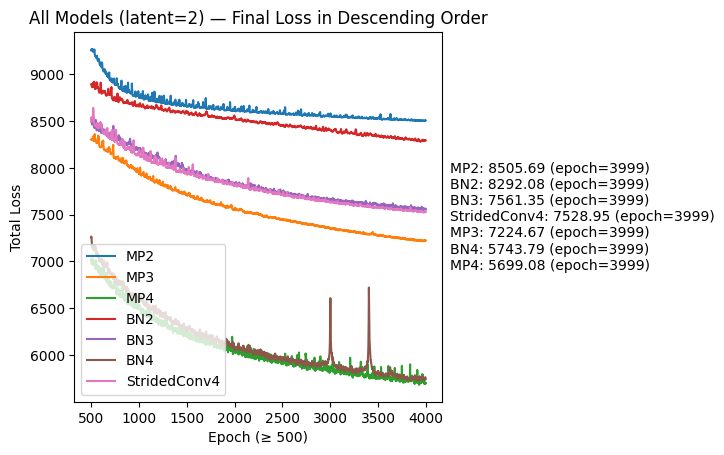

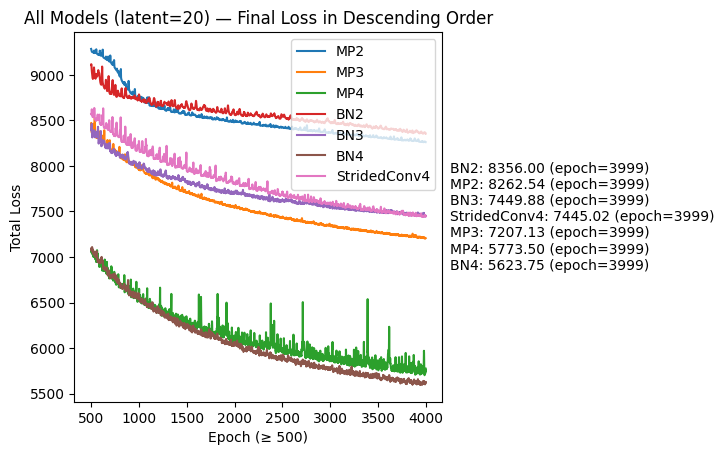

In [40]:
plot_total_loss_per_latent(data, model_names, [2, 20])

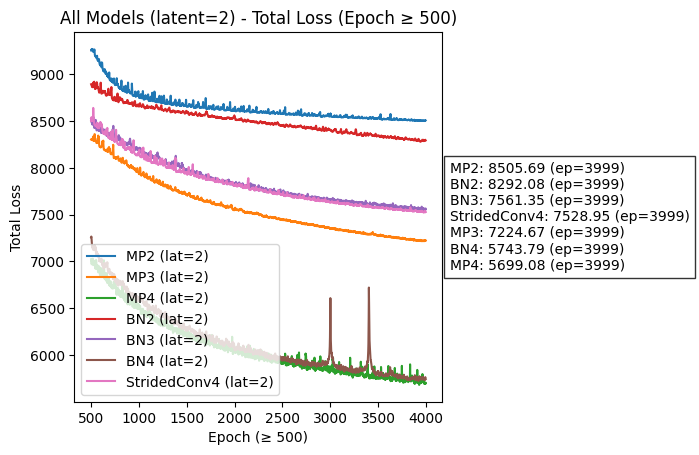

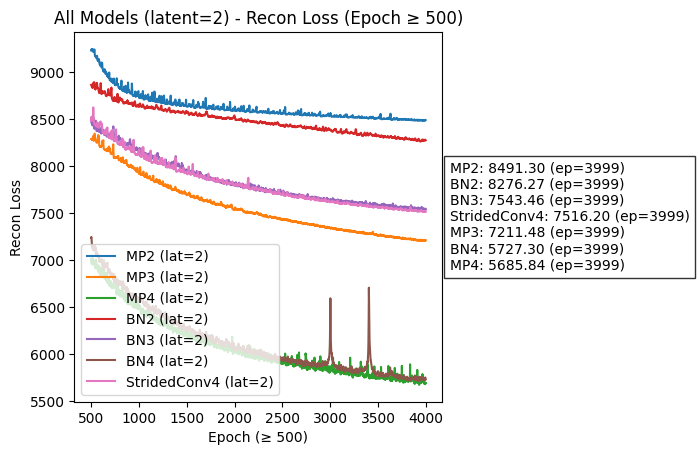

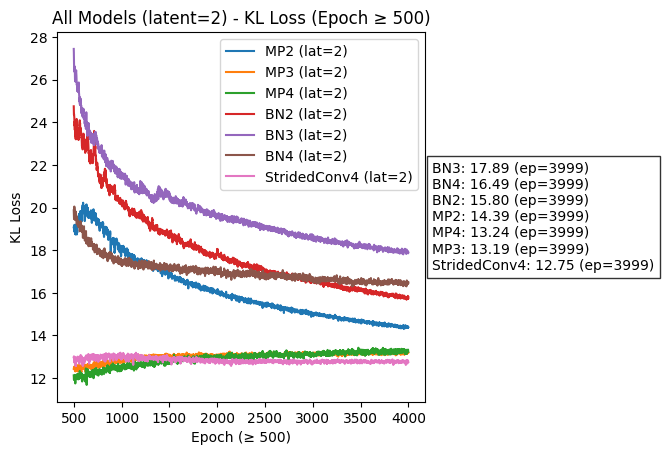

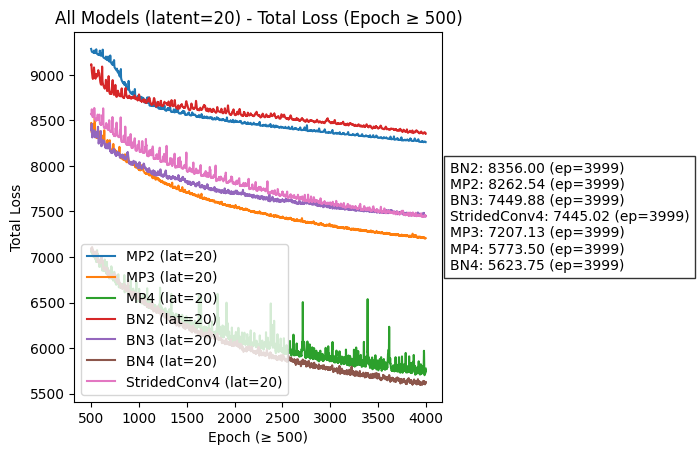

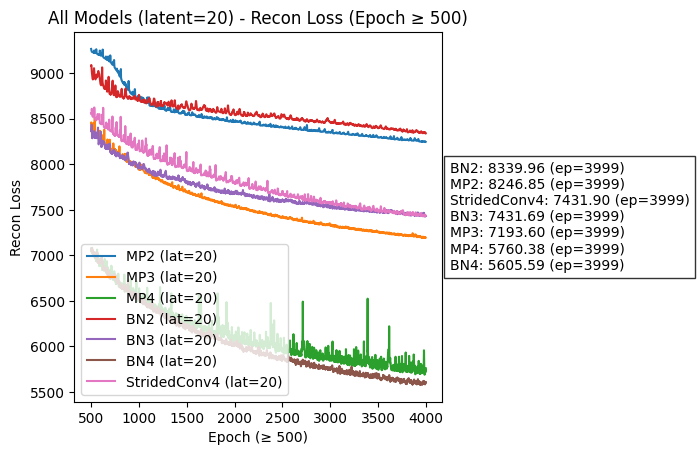

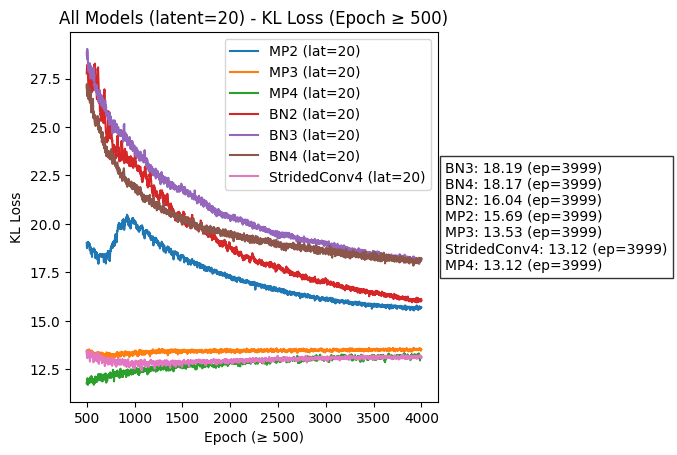

In [42]:
plot_all_losses_after_500_by_dim(data, latent_dims=[2, 20])